In [24]:
# Initialize Otter
import otter
grader = otter.Notebook("hw01.ipynb")

# HW 1A: Plotting and the Permutation Test
## Due Date: Thursday, January 25th, 11:59 PM

You must submit this assignment to Gradescope by the on-time deadline, Thursday, January 25th, at 11:59 PM. Please read the syllabus for the grace period policy. No late
submissions beyond the grace period will be accepted. While course staff is happy to help you if you encounter difficulties with submission, we may not be able to respond to late-night requests for assistance (TAs need to sleep, after all!). **We strongly encourage you to plan to submit your work to Gradescope several hours before the stated deadline.** This way, you will have ample time to contact staff for submission support. 

This is part of a two-part assignment. After completing this part ("Homework 1A"), please submit the generated zip file to the Homework 1 Coding assignment on Gradescope. Gradescope will automatically submit a PDF of your written responses to the HW 1A Written assignment; there is no need to submit it manually. Note that you will have to submit HW 1B manually and assign pages accordingly. 

## Collaboration Policy

Data science is a collaborative activity. While you may talk with others about
the homework, we ask that you **write your solutions individually**. If you 
discuss the assignments with others, please **include their names** below.

**Collaborators**: *list collaborators here*

## This Assignment

The purpose of this assignment is for you to combine Python, math, and the ideas in Data 8 to draw some interesting conclusions. The methods and results will help build the foundation of Data 100.

## Score Breakdown
Question | Manual? | Points
--- | --- | --
1a | No | 2
1b | No | 1
1c | Yes | 2
1d | No | 2
1e | Yes | 1
1f | No | 1
1g | Yes | 1
Total |   | 10

**Note**: "Manual" questions are written response questions that will be graded manually by the grading team instead of being graded by the autograder.

## Before You Start

### Syllabus Quiz

Make sure you complete the [Syllabus Quiz Gradescope assignment](https://www.gradescope.com/courses/696886/assignments/3932755) by **Thursday, January 25th, at 11:59 PM PT**. All answers to the questions can be found in the [syllabus on the course website](https://ds100.org/sp24/syllabus/).

### Autograder and Answer Cells

For each question in the assignment, please write down your answer in the answer cell(s) right below the question. 

We understand that it is helpful to have extra cells breaking down the process toward reaching your final answer. If you happen to create new cells *below* your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It may cause errors when we run the autograder, and it will cause a failure to generate the PDF file.


**Important note: The local autograder tests will not be comprehensive.** They are meant to give you some useful feedback, but it's your responsibility to ensure your response answers the question correctly. There may be other tests that we run when scoring your notebooks. We **strongly recommend** that you check your solutions yourself rather than just relying on the test cells.

### Initialize your environment

The below cell should run without error if you're using the course DataHub.

In [25]:
import numpy as np
np.random.seed(42)
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

### Preliminary: Jupyter Shortcuts ###

Here are some useful Jupyter notebook keyboard shortcuts.  To learn more keyboard shortcuts, go to **Help -> Keyboard Shortcuts** in the menu above. 

Here are a few we like:
1. `ctrl`+`return` : *run the current cell*
1. `shift`+`return`: *run the current cell and move to the next*
1. `esc` : *command mode* (may need to press before using any of the commands below)
1. `a` : *create a cell above*
1. `b` : *create a cell below*
1. `dd` : *delete a cell*
1. `m` : *convert a cell to markdown*
1. `y` : *convert a cell to code*

### Preliminary: `NumPy` ###

You should be able to understand the code in the following cells. If not, review the following:

* [Data 8 Textbook Chapter on NumPy](https://www.inferentialthinking.com/chapters/05/1/Arrays)
* [DS100 NumPy Review](http://ds100.org/fa17/assets/notebooks/numpy/Numpy_Review.html)
* [Condensed NumPy Review](http://cs231n.github.io/python-numpy-tutorial/#numpy)
* [The Official NumPy Tutorial](https://numpy.org/doc/stable/user/quickstart.html)

**Jupyter pro-tip**: Pull up the documentation for any function in Jupyter by running a cell with
the function name and a `?` at the end:

In [26]:
np.arange?

Docstring:
arange([start,] stop[, step,], dtype=None, *, like=None)

Return evenly spaced values within a given interval.

``arange`` can be called with a varying number of positional arguments:

* ``arange(stop)``: Values are generated within the half-open interval
  ``[0, stop)`` (in other words, the interval including `start` but
  excluding `stop`).
* ``arange(start, stop)``: Values are generated within the half-open
  interval ``[start, stop)``.
* ``arange(start, stop, step)`` Values are generated within the half-open
  interval ``[start, stop)``, with spacing between values given by
  ``step``.

For integer arguments the function is roughly equivalent to the Python
built-in :py:class:`range`, but returns an ndarray rather than a ``range``
instance.

When using a non-integer step, such as 0.1, it is often better to use
`numpy.linspace`.

See the Warning sections below for more information.

Parameters
----------
start : integer or real, optional
    Start of interval.  The interva

**Another Jupyter pro-tip**: Pull up the documentation for any function in Jupyter by typing the function
name, then `<Shift><Tab>` on your keyboard. This is super convenient when you forget the order
of the arguments to a function. You can press `<Tab>` multiple times to expand the docs and reveal additional information.

Try it on the function below:

In [27]:
np.linspace

<function linspace at 0x000001F87ED0A8B0>

### Preliminary: LaTeX ###
You should use LaTeX to format math in your answers. If you aren't familiar with LaTeX, don't worry. It's not hard to use in a Jupyter notebook. Just place your math in between dollar signs within Markdown cells:

`$ f(x) = 2x $` becomes $ f(x) = 2x $.

If you have a longer equation, use double dollar signs to place it on a line by itself:

`$$ \sum_{i=0}^n i^2 $$` becomes:

$$ \sum_{i=0}^n i^2$$


You can align multiple lines using the `&` anchor, `\\` newline, in an `align` block as follows:

```
\begin{align}
f(x) &= (x - 1)^2 \\
&= x^2 - 2x + 1
\end{align}
```
becomes

\begin{align}
f(x) &= (x - 1)^2 \\
&= x^2 - 2x + 1
\end{align}

* [This PDF](latex_tips.pdf) has some handy LaTeX tips.
* [For more about basic LaTeX formatting, you can read this article.](https://www.sharelatex.com/learn/Mathematical_expressions)


### Preliminary: Sums ###

Here's a recap of some basic algebra written in sigma notation. The facts are all just applications of the ordinary associative and distributive properties of addition and multiplication, written compactly and without the possibly ambiguous "$\dots$". But if you are ever unsure of whether you're working correctly with a sum, you can always try writing $\sum_{i=1}^n a_i$ as $a_1 + a_2 + \cdots + a_n$ and see if that helps.

You can use any reasonable notation for the index over which you are summing, just as in Python you can use any reasonable name in `for name in list`. Thus $\sum_{i=1}^n a_i = \sum_{k=1}^n a_k$.

- $\sum_{i=1}^n (a_i + b_i) = \sum_{i=1}^n a_i + \sum_{i=1}^n b_i$
- $\sum_{i=1}^n d = nd$
- $\sum_{i=1}^n (ca_i + d) = c\sum_{i=1}^n a_i + nd$

These properties may be useful in the future when we cover Least Squares Predictors. To see the LaTeX we used, double-click this cell. Evaluate the cell to exit.

<br/><br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Question 1: Distributions ##

Visualizing distributions, both categorical and numerical, helps us understand variability. In Data 8, you visualized numerical distributions by drawing histograms ([Chapter 7.2 link](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html#histogram)), which look like bar charts but represent proportions through the *areas* of the bars instead of the heights or lengths.


---

### Part 0: Matplotlib Tutorial

We will not be using Data 8's `datascience` library in this course. Instead, we will learn industry——and academia——standard libraries for exploring and visualizing data, including `matplotlib` ([official website](https://matplotlib.org/)).
In this exercise, you will use the `hist` function in `matplotlib` instead of the corresponding `Table` method to draw histograms. In a previous cell, we imported the matplotlib library as `plt`, which allows us to call `plt.hist()`.

To start off, suppose we want to plot the probability distribution of the number of spots on a single roll of a die. That should be a flat histogram since the chance of each of the values 1 through 6 is $\frac{1}{6}$. Here is a first attempt at drawing the histogram.

(array([1., 0., 1., 0., 1., 0., 1., 0., 1., 1.]),
 array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ]),
 <BarContainer object of 10 artists>)

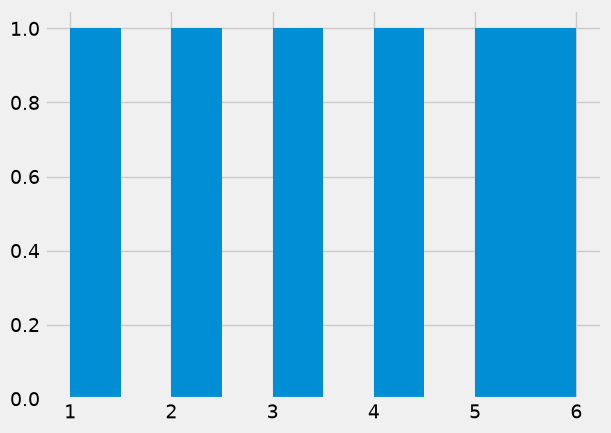

In [28]:
faces = range(1, 7)
plt.hist(faces)

This default plot is not helpful. We have to choose some arguments to get a visualization that we can interpret. 

Note that the second printed line shows the left ends of the default bins, as well as the right end of the last bin. The first line shows the counts in the bins. If you don't want the printed lines, you can add a semi-colon `;` at the end of the call to `plt.hist`, but we'll keep the lines for now.

Let's redraw the histogram with bins of unit length centered at the possible values. By the end of the tutorial, you'll see a reason for centering. Notice that the argument for specifying bins is the same as the one for the `Table` method `hist` from the `datascience` library in Data 8 ([link](http://data8.org/)).

(array([1., 1., 1., 1., 1., 1.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

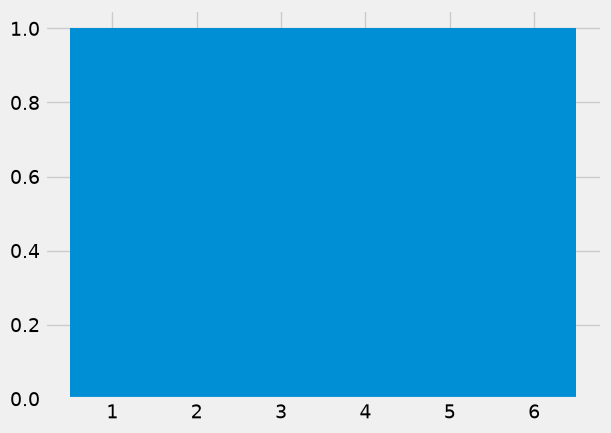

In [29]:
unit_bins = np.arange(0.5, 6.6)
plt.hist(faces, bins=unit_bins)

We need to see the edges of the bars! Let's specify the edge color `ec` to be `white`. [Here](https://matplotlib.org/3.5.3/gallery/color/named_colors.html) are all the colors you could use, but do try to drag yourself away from the poetic names.

(array([1., 1., 1., 1., 1., 1.]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

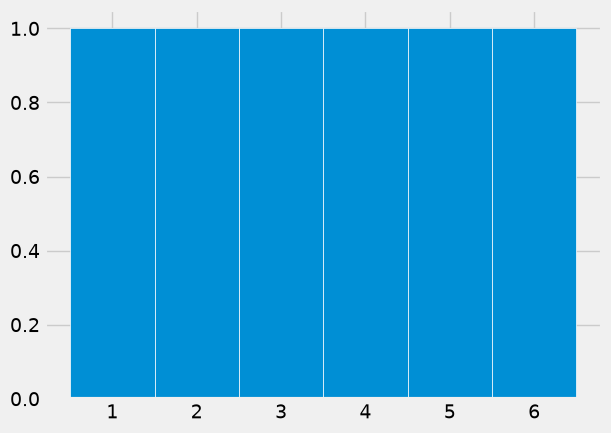

In [30]:
plt.hist(faces, bins=unit_bins, ec='white')

That's much better, but look at the vertical axis. It is not drawn to the density scale defined in Data 8 ([Chapter 7.2 link](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html#the-vertical-axis-density-scale)). We want a histogram of a probability distribution, so the total area should be 1. We just have to ask for that by setting `density` to `True`.

(array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

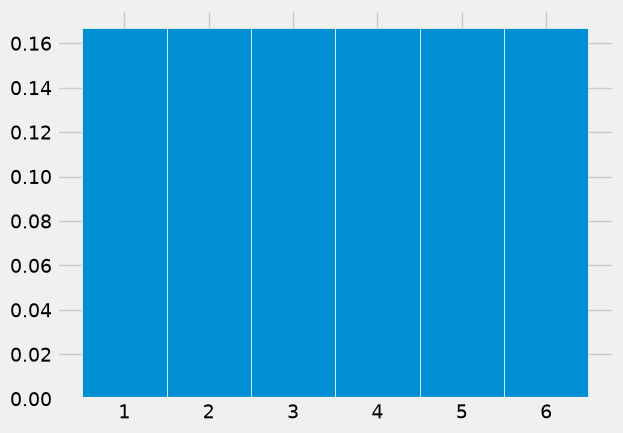

In [31]:
plt.hist(faces, bins=unit_bins, ec='white', density=True)

That's the probability histogram of the number of spots on one roll of a die. The proportion is $\frac{1}{6}$ in each of the bins.


Finally, we can set the opacity, or transparency, of the bars with the `alpha` parameter, which is a value from 0 to 1. For 70% opacity:

(array([0.16666667, 0.16666667, 0.16666667, 0.16666667, 0.16666667,
        0.16666667]),
 array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 <BarContainer object of 6 artists>)

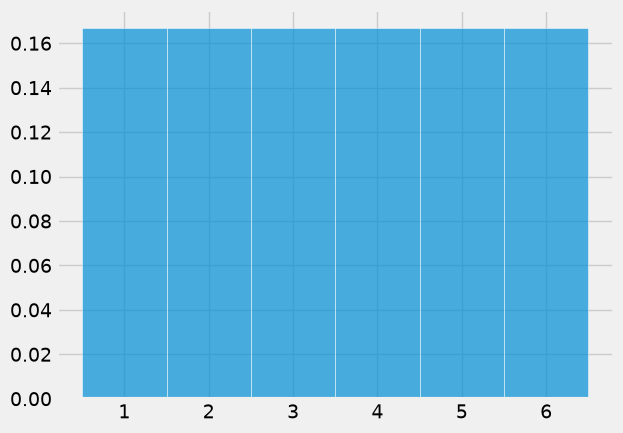

In [32]:
plt.hist(faces, bins=unit_bins, ec='white', density=True, alpha=0.7)

**Note/Reminder**: The above cells printed the counts/proportions and bin boundaries with the visualization. This was intentional on our part to show you how `plt.hist()` returned different values per plot. You may use a semicolon `;` on the last line to suppress additional display as needed.

<br/><br/>

---

### Question 1a

Define a function `plot_distribution` that takes an array of numbers (integers or decimals) and draws the histogram of the distribution using unit bins centered at the integers and white edges for the bars. The histogram should be drawn to the density scale, and the opacity should be 70\%. The left-most bar should be centered at the smallest integer in the range of the array and the right-most bar at the largest integer in the range of the array. The display does not need to include the printed proportions and bins. No titles or labels are required for this question. For grading purposes, assign your plot to `histplot`.

If you have trouble defining the function, go back and carefully read all the lines of code that resulted in the probability histogram of the number of spots on one roll of a die. Pay special attention to the bins. 

**Hint**: 
* See `plt.hist()` [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).
* What is the left endpoint of the left-most bar? What is the right endpoint of the right-most bar? You may find `min()`, `max()`, and `round()` helpful.
* If you implement the function correctly, you should get a plot like this:

<img src="q1a.png">

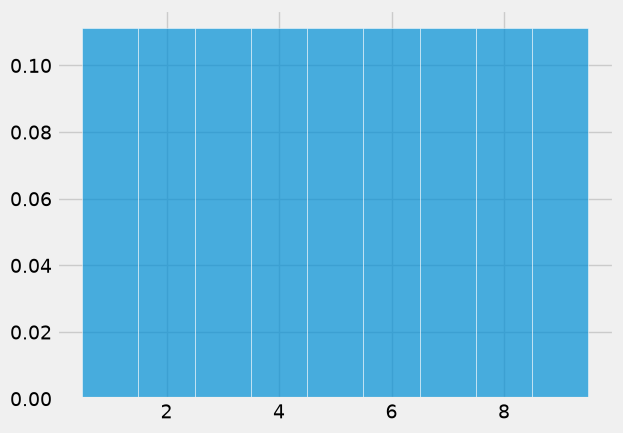

In [33]:
def plot_distribution(arr):
    arr = np.array(arr)
    min_int = int(np.floor(np.min(arr)))
    max_int = int(np.ceil(np.max(arr)))
    unit_bins = np.arange(min_int - 0.5, max_int + 1)
    histplot = plt.hist(arr, bins=unit_bins, ec='white', density=True, alpha=0.7)
    return histplot
faces = range(1, 10)
histplot = plot_distribution(faces)

In [34]:
grader.check("q1a")

q1a results: All test cases passed!

<br/>

---

### Tutorial: Birthweights

Recall from Data 8 that you can perform [hypothesis testing using the permutation test](https://inferentialthinking.com/chapters/12/1/AB_Testing.html) (Chapter 12.1). **Before continuing, we HIGHLY ENCOURAGE you to read the above linked Data 8 chapters, on which this exercise is DIRECTLY BASED.**

In a particular medical study, a sample of newborn babies was obtained from a large hospital system.  We will treat the data as if it were a simple random sample, though the sampling was done in multiple stages. Deborah Nolan and Terry Speed discuss the larger dataset in [Stat Labs](https://www.stat.berkeley.edu/~statlabs/).

One of the aims of the study was to see whether maternal smoking was associated with birth weight. **Run the below cell**, which assigns `nonsmoker_births` to a list of birth weights of the babies of the non-smoking mothers (of which there are 715) and `smoker_births` to a list of birth weights of the babies of the smoking mothers (of which there are 459). 

In [35]:
# Just run this cell. You will learn these functions soon!

import pandas as pd
births_df = pd.read_csv("births.csv")

nonsmoker_births = births_df[~births_df['Maternal Smoker']]['Birth Weight'].values
print(len(nonsmoker_births))

smoker_births = births_df[births_df['Maternal Smoker']]['Birth Weight'].values
print(len(smoker_births))

715
459


Suppose that we overlay the distributions of birthweights from the two groups:

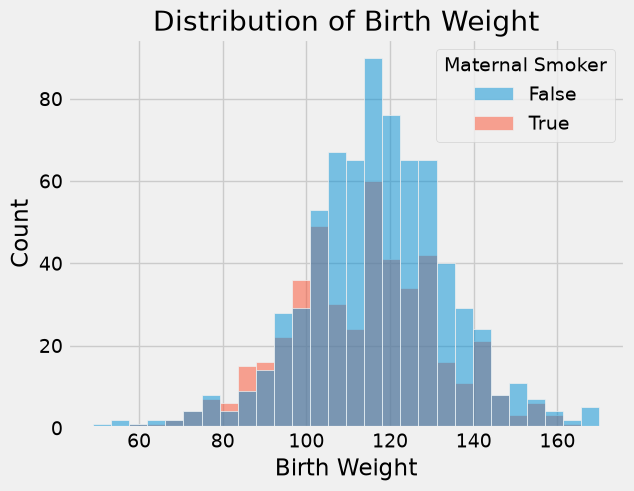

In [36]:
# Just run this cell. You will learn these functions soon!

import seaborn as sns
sns.histplot(births_df, x="Birth Weight", hue="Maternal Smoker");
plt.title("Distribution of Birth Weight");

The distribution of the weights of the babies born to mothers who smoked appears to be based slightly to the left of the distribution corresponding to non-smoking mothers. The weights of the babies of the mothers who smoked seem lower on average than those of the babies of the non-smokers.

<br/>
Similar to the original study (and the Data 8 chapter), we'd like to study whether this difference reflects just chance variation or perhaps a difference in the distributions in the larger population. Suppose we propose the following two hypotheses:

> **Null hypothesis (H0)**: In the population, the distribution of birth weights of babies is the same for mothers who don’t smoke as for mothers who do. The (observed) difference in the sample is due to chance.

> **Alternative hypothesis (H1)**: In the population, the babies of the mothers who smoke have a <i>**different**</i> birth weight, on average, than the babies of the non-smokers.

We would like to perform hypothesis testing using the permutation test. One way to do so is to compute an observed test statistic and then compare it with multiple simulated test statistics generated through random permutations.

<br/><br/>

---

### Question 1b

Suppose that we choose a reasonable test statistic as the **absolute difference** between the average birth weights of the two groups (i.e., the babies of non-smokers and the babies of mothers who smoke). 

In the below cell, assign `observed_difference` to the **observed test statistic** given our original sample of `nonsmoker_births` and `smoker_births`.

**Hint**: This test statistic is slightly different from what is presented in the Data 8 textbook, [Chapter 12.1 link](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#the-hypotheses).

In [37]:
observed_difference = np.mean(nonsmoker_births) - np.mean(smoker_births)
observed_difference

3.2661425720249184

In [38]:
grader.check("q1b")

q1b results: All test cases passed!

<!-- BEGIN QUESTION -->

<br/><br/>

---

### Question 1c

Before we write any code, let’s review the idea of hypothesis testing with the permutation test. We first simulate the experiment many times (say, 10,000 times) through random permutation (i.e., without replacement). Assuming that the null hypothesis holds, this process will produce an empirical distribution of a predetermined test statistic. Then, we use this empirical distribution to compute an empirical p-value, which is then compared against a particular cutoff threshold in order to accept or reject our null hypothesis. 

In the below cell, answer the following questions:
* What does an empirical p-value from a permutation test mean in this particular context of birthweights and maternal smoking habits?
* Suppose the resulting empirical p-value $p \leq 0.01$, where $0.01$ is our p-value cutoff threshold. Do we accept or reject the null hypothesis? Why?


**1. What does the empirical p-value mean in this context?**

In this birthweight study, the empirical p-value is the proportion of the 10,000 permuted samples in which the absolute difference between the mean birth weights of the two randomly labeled groups is at least as large as the observed absolute difference in our original data. Each permutation simulates what the test statistic would look like if maternal smoking had no association with birth weight (i.e., if the null hypothesis were true). So the empirical p-value measures how likely it is to see a difference as extreme as the one we observed, purely due to random assignment of smoking labels.

**2. If $p \leq 0.01$, do we accept or reject the null hypothesis? Why?**

We **reject** the null hypothesis. With a cutoff of 0.01, a p-value at or below 0.01 means that differences at least as large as the one we observed would occur in 1% or fewer of permutations under the null. That is strong evidence against the claim that smoking status and birth weight are unrelated, so we conclude that maternal smoking is associated with a difference in average birth weight.

<!-- END QUESTION -->

<br/><br/>

---

### Question 1d

Now, we begin the permutation test by generating an array called `differences` that contains simulated values of our test statistic from **10,000 permuted samples**. Again, note that our test statistic differs from what is in the Data 8 textbook: we are computing the absolute difference between the mean weight in the smoking group and the mean weight in the non-smoking group, where labels have been assigned at random.

**Reminder**: Data 100 does **not** support the `datascience` library, so you should instead use the appropriate functions from the `NumPy` library. Some suggested references: Lab 01 (for a quick `NumPy` tutorial), `NumPy` array indexing/slicing [documentation](https://numpy.org/doc/stable/user/basics.indexing.html), `np.random.choice` [documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html), and `np.append` [documentation](https://numpy.org/doc/stable/reference/generated/numpy.append.html).

**Note**: We have provided some optional skeleton code below, but you do not need to follow it. Please assign simulated differences to the array `differences`.

In [39]:
# Do not modify this line.
np.random.seed(42)

# Create an empty array to hold our simulated differences
differences = np.array([]) 
# Set number of repetitions
repetitions = 10000
# Combine the two arrays into a single array
all_birthweights = np.append(nonsmoker_births, smoker_births)

for i in np.arange(repetitions):
    # Permute all_birthweights
    shuffled_birthweights = np.random.permutation(all_birthweights)

    # Make the simulated smoker and non-smoker group
    sim_nonsmoker_births = shuffled_birthweights[:len(nonsmoker_births)]
    sim_smoker_births = shuffled_birthweights[len(nonsmoker_births):]
    
    # Calculate test statistics
    sim_difference = abs(np.mean(sim_smoker_births) - np.mean(sim_nonsmoker_births))
    
    # Append the test statistics in differences
    differences = np.append(differences, sim_difference)

differences

array([0.27198379, 0.40791931, 2.88337675, ..., 1.02298094, 0.55793836,
       0.12509103])

In [40]:
grader.check("q1d")

q1d results: All test cases passed!

<!-- BEGIN QUESTION -->

<br/><br/>

---

### Question 1e

The array `differences` is an empirical distribution of the test statistic simulated under the null hypothesis. This is a prediction about the test statistic, based on the null hypothesis.

Use the `plot_distribution` function you defined in an earlier part to plot a histogram of this empirical distribution. Because you are using this function, your histogram should have unit bins, with bars centered at integers. No title or labels are required for this question.

**Hint**: This part should be very straightforward.


(array([0.3558, 0.4825, 0.142 , 0.0179, 0.0018, 0.    ]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]),
 <BarContainer object of 6 artists>)

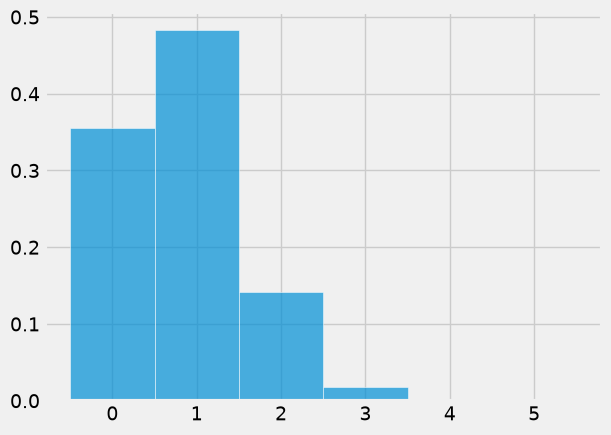

In [41]:
plot_distribution(differences)

<!-- END QUESTION -->

<br/><br/>

---

### Question 1f

Compute `empirical_p`, the empirical p-value based on `differences`, the empirical distribution of the test statistic, and `observed_difference`, the observed value of the test statistic.

**Hint**: 
* Review the conclusion of the [Data 8 textbook example](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#conclusion-of-the-test) in Chapter 12.1.
* There are two main differences between this example and the Data 8 example. The first being that our test statistic is different. The second is that our hypothesis is different. How can you adjust the code from the Data 8 example to calculate `empirical_p`?

In [42]:
empirical_p = np.count_nonzero(differences >= abs(observed_difference)) / len(differences)
empirical_p

0.0026

In [43]:
grader.check("q1f")

q1f results: All test cases passed!

<!-- BEGIN QUESTION -->

<br/><br/>

---

### Question 1g

Based on your computed empirical p-value, do we reject or fail to reject the null hypothesis? Use the p-value cutoff proposed in Question 1c of 0.01, or 1%. 


We **reject** the null hypothesis.

Our empirical p-value is about 0.0026, which is less than the 0.01 cutoff. This means that under the null hypothesis (maternal smoking has no association with birth weight), a difference at least as large as the one we observed would occur in only about 0.26% of permutations. Since this probability is below 1%, we have statistically significant evidence that maternal smoking is associated with a difference in average birth weight.

<!-- END QUESTION -->

<br/><br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Homework 1A!

Soda, Momo, and Causality are here to congratulate you :)

<img src = "soda-momo.png" width = "500"> <img src = "caus.jpg" width = "250">


### Submission Instructions

Below, you will see one cell. Running this will automatically generate a zip file with your answers. Please submit this file to the Homework 1A Coding assignment on Gradescope. Gradescope will automatically submit the PDF from this file to the Homework 1A Written assignment. **There is no need to manually submit Homework 1A Written answers; however, please check that the PDF was generated and submitted correctly**.

You are responsible for submitting the zip file generated below as well as a PDF with your answers to Homework 1B. **You are also responsible for submitting the [Syllabus Quiz Gradescope assignment](https://www.gradescope.com/courses/696886/assignments/3932755).**
* **Homework 1 Coding**: Submit your Jupyter Notebook zip file for Homework 1A,
which can be generated and downloaded from DataHub by using the `grader.export()`
cell provided below.
* **Homework 1A Written**: Gradescope will automatically submit the PDF from the zip file submitted earlier. You do not need to submit anything to this assignment yourself, but please check that the submission went through properly.  
* **Homework 1B**: Submit a PDF to Gradescope that contains your answers to all questions in Homework 1B.
* **[Syllabus Quiz](https://www.gradescope.com/courses/696886/assignments/3932755)**: The assignment is multiple-choice style on Gradescope. You may change or update your answers anytime before the deadline.

**Important**: When submitting Homework 1B on Gradescope, you **must tag pages to each question correctly** (it prompts you to do this after submitting your work). This significantly streamlines the grading process for our readers. Failure to do this may result in a score of 0 for untagged questions.

To receive credit on this assignment, **you must submit both your coding and written
portions to their respective Gradescope portals as well as the syllabus quiz.** 

**You are responsible for ensuring your submission follows our requirements and that the automatic submission for Homework 1A Written answers went through properly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline.

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)

c:\Users\Splendid\Desktop\Charles\01-Project\03-Data100\.venv\Lib\site-packages\otter\check\notebook.py:494: UserWarning: Could not locate a PDF to include
  warnings.warn("Could not locate a PDF to include")
